# Exercise 3

## Imports

In [58]:
import math
import os
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydub import AudioSegment
from scipy.io import arff

## Constants

In [59]:
current_dir = Path.cwd()

# Music file
classical_audiofile_path = current_dir.joinpath("data", "classical.mp3")

# Features
features_folder_path = current_dir.joinpath("data", "features")

# Audio chunks output
audio_chunks_output_path = current_dir.joinpath("data", "outputs", "audio_chunks")

## Exercise 1

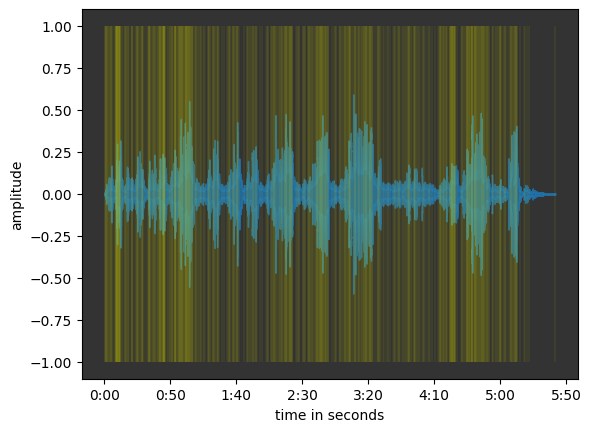

In [60]:
y, sr = librosa.load(classical_audiofile_path)
duration_sec = len(y) / sr
duration_ms = duration_sec * 1000

onsets = librosa.onset.onset_detect(y=y, sr=sr)
onset_times = librosa.frames_to_time(onsets, sr=sr)

# plot everything
plt.figure()
ax = plt.subplot(1, 1, 1)
ax.set_facecolor("#333333")

librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.8)

ax.vlines(onset_times, -1, 1, linestyle="-", alpha=0.05, color="yellow")
ax.set_xlabel("time in seconds")
ax.set_ylabel("amplitude")

plt.show()

## Exercise 2

In [61]:
# SPLIT AUDIO INTO 5s CHUNKS
audio = AudioSegment.from_mp3(classical_audiofile_path)

chunk_seconds = 5
chunk_length_ms = chunk_seconds * 1000

chunk_onsets = []
onset_frames = []
non_onset_frames = []
for i in range(0, len(audio), chunk_length_ms):
    chunk_id = i // chunk_length_ms
    chunk = audio[i:i + chunk_length_ms]
    chunk_file_name = f"chunk_{chunk_id}.mp3"
    chunk_path = audio_chunks_output_path.joinpath(chunk_file_name)

    chunk.export(chunk_path, format="mp3")

    # For ex2
    y, sr = librosa.load(chunk_path)
    onsets = librosa.onset.onset_detect(y=y, sr=sr)
    chunk_onsets.append(len(onsets))
    print(f"chunk {chunk_id} -> nº onsets = {len(onsets)}")

    # For ex3
    # TODO: fill onset_frames
    # TODO: non_onset_frames

chunk 0 -> nº onsets = 13
chunk 1 -> nº onsets = 19
chunk 2 -> nº onsets = 28
chunk 3 -> nº onsets = 10
chunk 4 -> nº onsets = 12
chunk 5 -> nº onsets = 15
chunk 6 -> nº onsets = 11
chunk 7 -> nº onsets = 15
chunk 8 -> nº onsets = 19
chunk 9 -> nº onsets = 21
chunk 10 -> nº onsets = 19
chunk 11 -> nº onsets = 21
chunk 12 -> nº onsets = 25
chunk 13 -> nº onsets = 14
chunk 14 -> nº onsets = 13
chunk 15 -> nº onsets = 14
chunk 16 -> nº onsets = 16
chunk 17 -> nº onsets = 13
chunk 18 -> nº onsets = 15
chunk 19 -> nº onsets = 13
chunk 20 -> nº onsets = 13
chunk 21 -> nº onsets = 14
chunk 22 -> nº onsets = 17
chunk 23 -> nº onsets = 18
chunk 24 -> nº onsets = 17
chunk 25 -> nº onsets = 15
chunk 26 -> nº onsets = 19
chunk 27 -> nº onsets = 18
chunk 28 -> nº onsets = 18
chunk 29 -> nº onsets = 14
chunk 30 -> nº onsets = 14
chunk 31 -> nº onsets = 20
chunk 32 -> nº onsets = 22
chunk 33 -> nº onsets = 18
chunk 34 -> nº onsets = 18
chunk 35 -> nº onsets = 13
chunk 36 -> nº onsets = 19
chunk 37 ->

In [62]:
# READ FEATURES AND MERGE THEM BY CHUNKS
arff_files = sorted(
    [os.path.join(features_folder_path, f) for f in os.listdir(features_folder_path) if f.endswith(".arff")])

# Read features
dfs = []
for f in arff_files:
    data, meta = arff.loadarff(f)
    df = pd.DataFrame(data)
    df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)
    df = df.apply(pd.to_numeric, errors='coerce')
    df.set_index('WindowNumber', inplace=True)
    dfs.append(df)
features_df = pd.concat(dfs, axis=1)
print(features_df)

num_windows = features_df.shape[0]
print(f"Number of feature windows: {num_windows}")
print(f"Duration of piece (ms): {duration_ms:.2f}")

windows_per_chunk = math.floor(num_windows / duration_ms * chunk_length_ms)
print(f"Windows per chunk aprox: {windows_per_chunk}")

# Merge by chunks
avg_features_per_chunk_df = features_df.groupby(np.arange(len(features_df)) // windows_per_chunk).mean(
    numeric_only=True)
avg_features_per_chunk_df.index = range(0, len(avg_features_per_chunk_df))
avg_features_per_chunk_df.rename_axis('chunk_id', inplace=True)

print(avg_features_per_chunk_df)

/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_81661/3368848716.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


              Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0                 0.015625          2085.8660                1.056783   
14720.0                 0.025391          1828.1770 

Plotting for feature: Zero-crossing rate
Plotting for feature: Spectral centroid
Plotting for feature: Angles in phase domain
Plotting for feature: Distances in phase domain
Plotting for feature: Root mean square
Plotting for feature: Low energy


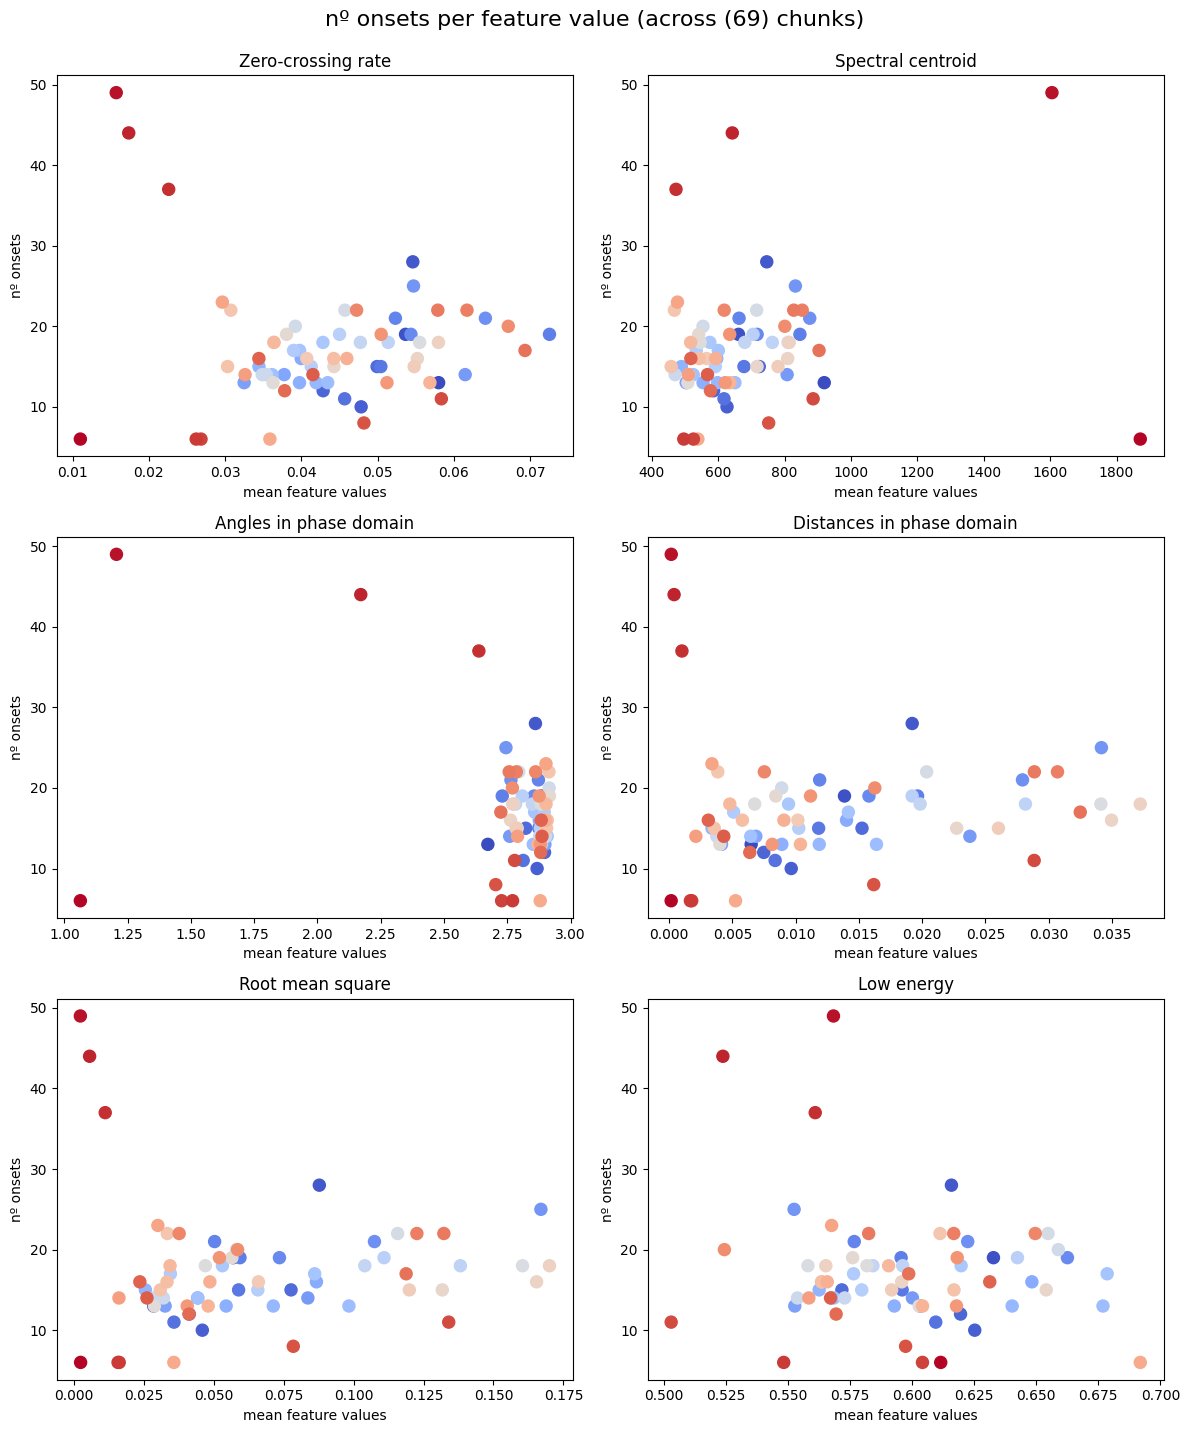

In [72]:
# PLOT [nº ONSETS X avg FEATURE VALUE]

def plot_features(df: pd.DataFrame):
    plt.figure(figsize=(12, 14))
    colors = np.arange(len(chunk_onsets))

    for f_idx, feature in enumerate(features_df.columns):
        print(f"Plotting for feature: {feature}")

        plt.subplot(3, 2, f_idx + 1)

        plt.scatter(df[feature], chunk_onsets, c=colors, cmap='coolwarm', marker='o', s=75)
        #plt.scatter(df[feature], chunk_onsets, c="blue", marker='o', s=75)

        plt.title(f"{feature}")
        plt.xlabel("mean feature values")
        plt.ylabel("nº onsets")
        plt.tight_layout()

    plt.suptitle(f"nº onsets per feature value (across ({len(chunk_onsets)}) chunks)", fontsize=16, y=1.02)
    plt.show()


plot_features(avg_features_per_chunk_df)

## Exercise 3

In [ ]:
# TODO: create new data frames from selected frames

onset_frames_df = None

non_onset_frames_df = None

In [ ]:
plot_features(onset_frames_df)

In [ ]:
plot_features(non_onset_frames_df)